Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Colab cache for faster access to the 'asl-alphabet' dataset.
Path to dataset files: /kaggle/input/asl-alphabet

✅ Dataset path : /kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train
Classes found  : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Total classes  : 29

Creating 20% subset...

✅ Subset created at /content/asl_subset
   A: 600 images
   B: 600 images
   C: 600 images
   D: 600 images
   E: 600 images
   F: 600 images
   G: 600 images
   H: 600 images
   I: 600 images
   J: 600 images
   K: 600 images
   L: 600 images
   M: 600 images
   N: 600 images
   O: 600 images
   P: 600 images
   Q: 600 images
   R: 600 images
   S: 600 images
   T: 600 images
   U: 600 images
   V: 600 images
   W: 600 images
   X: 600 images
   

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,057,757 (11.66 MB)

 Trainable params: 797,213 (3.04 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


PHASE 1: Training top layers (base frozen)
Epoch 1/4
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 944ms/step - accuracy: 0.4748 - loss: 2.0383
Epoch 1: val_accuracy improved from None to 0.78707, saving model to /content/drive/MyDrive/ASL DATASET/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ASL DATASET/best_model.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.6500 - loss: 1.3151 - val_accuracy: 0.7871 - val_loss: 0.8080 - learning_rate: 0.0010
Epoch 2/4
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 920ms/step - accuracy: 0.8273 - loss: 0.6589
Epoch 2: val_accuracy improved from 0.78707 to 0.81782, saving model to /content/drive/MyDrive/ASL DATASET/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ASL DATASET/best_model.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 207s 951ms/step - accuracy: 0.8411 - loss: 0.6240 - val_accuracy: 0.8178 - val_loss: 0.7133 - learning_rate: 0.0010
Epoch 3/4
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 914ms/step - accuracy: 0.8661 - lo

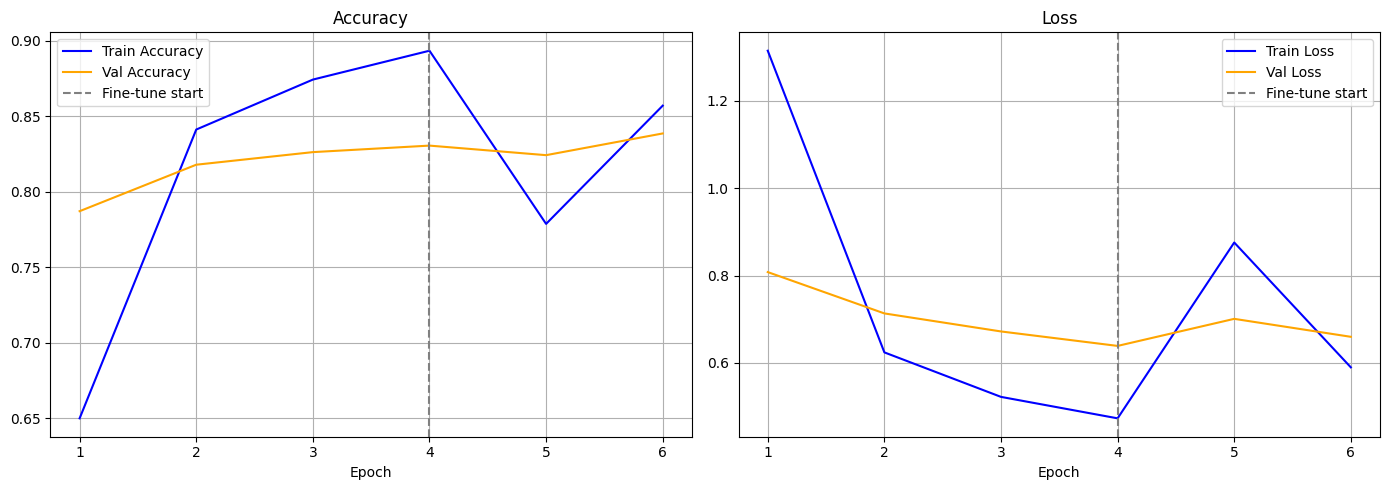

📊 Plot saved to Drive!

Evaluating on validation set...
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - accuracy: 0.8385 - loss: 0.6597

✅ Final Validation Accuracy: 83.85%
✅ Final Validation Loss    : 0.6597


In [ ]:
# ============================================================
# Sign Language Model Training - 29 Classes
# ASL Alphabet (A-Z) + SPACE + DELETE + NOTHING
# Dataset: grassknoted/asl-alphabet (87,000 images, 200x200)
# Using 20% subset per class, 4+2 epochs
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import json
import shutil
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

# ── 1. Download Dataset via KaggleHub ────────────────────────
import kagglehub
path = kagglehub.dataset_download("grassknoted/asl-alphabet")
print("Path to dataset files:", path)

# ── 2. Locate Training Folder ────────────────────────────────
BASE_PATH    = "/kaggle/input/asl-alphabet"
DATASET_PATH = os.path.join(BASE_PATH, "asl_alphabet_train", "asl_alphabet_train")

classes = sorted(os.listdir(DATASET_PATH))
print(f"\n✅ Dataset path : {DATASET_PATH}")
print(f"Classes found  : {classes}")
print(f"Total classes  : {len(classes)}")

NUM_CLASSES = len(classes)

DRIVE_PATH = "/content/drive/MyDrive/ASL DATASET/"
os.makedirs(DRIVE_PATH, exist_ok=True)

# ── 3. Take 20% Images from Each Class ───────────────────────
SUBSET_PATH = "/content/asl_subset"

if not os.path.exists(SUBSET_PATH):
    os.makedirs(SUBSET_PATH)
    random.seed(42)

    print("\nCreating 20% subset...")
    for cls in sorted(os.listdir(DATASET_PATH)):
        cls_src  = os.path.join(DATASET_PATH, cls)
        cls_dest = os.path.join(SUBSET_PATH, cls)
        if not os.path.isdir(cls_src):
            continue

        os.makedirs(cls_dest, exist_ok=True)
        all_images = os.listdir(cls_src)
        subset     = random.sample(all_images, max(1, int(len(all_images) * 0.20)))

        for img in subset:
            shutil.copy(
                os.path.join(cls_src, img),
                os.path.join(cls_dest, img)
            )

    print(f"\n✅ Subset created at {SUBSET_PATH}")
    total = 0
    for cls in sorted(os.listdir(SUBSET_PATH)):
        n = len(os.listdir(os.path.join(SUBSET_PATH, cls)))
        total += n
        print(f"   {cls}: {n} images")
    print(f"\n   Total images in subset: {total}")
else:
    print("✅ Subset already exists, skipping copy.")
    total = sum(
        len(os.listdir(os.path.join(SUBSET_PATH, cls)))
        for cls in os.listdir(SUBSET_PATH)
        if os.path.isdir(os.path.join(SUBSET_PATH, cls))
    )
    print(f"   Total images in subset: {total}")

# ── 4. Hyperparameters ───────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 64
EPOCHS_1   = 4
EPOCHS_2   = 2

# ── 5. Data Augmentation ─────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=False,        # ❌ ASL signs are hand-specific
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    SUBSET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_data = val_datagen.flow_from_directory(
    SUBSET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f"\nTraining samples  : {train_data.samples}")
print(f"Validation samples: {val_data.samples}")
print(f"Number of classes : {train_data.num_classes}")
print(f"Class mapping     : {train_data.class_indices}")

# ── 6. Save Labels ───────────────────────────────────────────
labels = train_data.class_indices
with open(DRIVE_PATH + "labels.json", "w") as f:
    json.dump(labels, f, indent=2)
print("\n✅ Labels saved to Drive!")
print("All labels:", labels)

# ── 7. Build Model ───────────────────────────────────────────
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ── 8. Callbacks ─────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_accuracy', patience=3,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=2, min_lr=1e-7, verbose=1
)
checkpoint = ModelCheckpoint(
    DRIVE_PATH + "best_model.keras",
    monitor='val_accuracy', save_best_only=True, verbose=1
)

# ── 9. Phase 1: Train Top Layers ─────────────────────────────
print("\n" + "="*50)
print("PHASE 1: Training top layers (base frozen)")
print("="*50)

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_1,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# ── 10. Phase 2: Fine-Tune Last 30 Layers ────────────────────
print("\n" + "="*50)
print("PHASE 2: Fine-tuning last 30 layers")
print("="*50)

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop2 = EarlyStopping(
    monitor='val_accuracy', patience=3,
    restore_best_weights=True, verbose=1
)
reduce_lr2 = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=2, min_lr=1e-8, verbose=1
)
checkpoint2 = ModelCheckpoint(
    DRIVE_PATH + "best_model_finetuned.keras",
    monitor='val_accuracy', save_best_only=True, verbose=1
)

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_2,
    callbacks=[early_stop2, reduce_lr2, checkpoint2]
)

# ── 11. Save Final Model ──────────────────────────────────────
model.save(DRIVE_PATH + "sign_model_final.keras")
print("\n✅ Final model saved!")

# ── 12. Plot Training History ─────────────────────────────────
def plot_history(h1, h2):
    acc   = h1.history['accuracy']     + h2.history['accuracy']
    val   = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss  = h1.history['loss']         + h2.history['loss']
    vloss = h1.history['val_loss']     + h2.history['val_loss']
    ep    = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(ep, acc,  label='Train Accuracy', color='blue')
    axes[0].plot(ep, val,  label='Val Accuracy',   color='orange')
    axes[0].axvline(len(h1.history['accuracy']), color='gray',
                    linestyle='--', label='Fine-tune start')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(ep, loss,  label='Train Loss', color='blue')
    axes[1].plot(ep, vloss, label='Val Loss',   color='orange')
    axes[1].axvline(len(h1.history['loss']), color='gray',
                    linestyle='--', label='Fine-tune start')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(DRIVE_PATH + "training_history.png", dpi=150)
    plt.show()
    print("📊 Plot saved to Drive!")

plot_history(history1, history2)

# ── 13. Evaluate ──────────────────────────────────────────────
print("\nEvaluating on validation set...")
loss, acc = model.evaluate(val_data, verbose=1)
print(f"\n✅ Final Validation Accuracy: {acc*100:.2f}%")
print(f"✅ Final Validation Loss    : {loss:.4f}")